In [1]:
#imports
import os
import time
import pandas as pd
import drms
from datetime import datetime, timedelta


In [12]:
c = drms.Client()


In [13]:
# Output directory
OUT_DIR = "data/raw_metadata"
os.makedirs(OUT_DIR, exist_ok=True)

# SHARP metadata keys (subset used by Bobra-style models)
SHARP_KEYS = [
    "T_REC",
    "HARPNUM",
    "NOAA_ARS",
    "USFLUX",
    "R_VALUE",
    "MEANGAM",
    "MEANGBT",
    "MEANGBZ",
    "TOTUSJZ",
    "TOTUSJH",
    "AREA_ACR",
    "QUALITY"
]

KEY_STR = ",".join(SHARP_KEYS)

# Date range (CHANGE AS NEEDED)
START_DATE = "2010.05.01"
END_DATE   = "2020.12.31"

MAX_RETRIES = 5


In [14]:
#function deifnition
def fetch_and_save_day(date_str):
    out_file = f"{OUT_DIR}/sharp_meta_{date_str}.parquet"

    # Skip if already done
    if os.path.exists(out_file):
        print(f"[SKIP] {date_str}")
        return

    ds = f"hmi.sharp_cea_720s[][${date_str}_00:00:00_TAI/1d][? QUALITY < 65536 ?]".replace("$", "")

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            df = c.query(ds, key=KEY_STR)

            if df.empty:
                print(f"[WARN] {date_str} → no records")
                return

            # FIX: handle TAI timestamps correctly
            df["T_REC"] = pd.to_datetime(
                df["T_REC"].str.replace("_TAI", "", regex=False),
                format="%Y.%m.%d_%H:%M:%S"
            )

            df.sort_values(["HARPNUM", "T_REC"], inplace=True)
            df.reset_index(drop=True, inplace=True)

            df.to_parquet(out_file, index=False)
            print(f"[OK] {date_str} → {len(df)} rows")
            return

        except Exception as e:
            print(f"[ERR] {date_str} attempt {attempt}/{MAX_RETRIES}: {e}")
            time.sleep(10 * attempt)

    print(f"[FAIL] {date_str} after {MAX_RETRIES} attempts")


In [15]:
#10 year query
start = datetime.strptime(START_DATE, "%Y.%m.%d")
end   = datetime.strptime(END_DATE, "%Y.%m.%d")

current = start
while current < end:
    day_str = current.strftime("%Y.%m.%d")
    fetch_and_save_day(day_str)
    current += timedelta(days=1)


[OK] 2010.05.01 → 444 rows
[OK] 2010.05.02 → 489 rows
[OK] 2010.05.03 → 742 rows
[OK] 2010.05.04 → 721 rows
[OK] 2010.05.05 → 793 rows
[OK] 2010.05.06 → 667 rows
[OK] 2010.05.07 → 518 rows
[OK] 2010.05.08 → 429 rows
[OK] 2010.05.09 → 330 rows
[OK] 2010.05.10 → 232 rows
[OK] 2010.05.11 → 165 rows
[OK] 2010.05.12 → 162 rows
[OK] 2010.05.13 → 195 rows
[OK] 2010.05.14 → 189 rows
[OK] 2010.05.15 → 92 rows
[WARN] 2010.05.16 → no records
[WARN] 2010.05.17 → no records
[WARN] 2010.05.18 → no records
[OK] 2010.05.19 → 301 rows
[OK] 2010.05.20 → 365 rows
[OK] 2010.05.21 → 417 rows
[OK] 2010.05.22 → 479 rows
[OK] 2010.05.23 → 585 rows
[OK] 2010.05.24 → 557 rows
[OK] 2010.05.25 → 720 rows
[OK] 2010.05.26 → 649 rows
[OK] 2010.05.27 → 539 rows
[OK] 2010.05.28 → 666 rows
[OK] 2010.05.29 → 679 rows
[OK] 2010.05.30 → 543 rows
[OK] 2010.05.31 → 481 rows
[OK] 2010.06.01 → 475 rows
[OK] 2010.06.02 → 514 rows
[OK] 2010.06.03 → 532 rows
[OK] 2010.06.04 → 463 rows
[OK] 2010.06.05 → 403 rows
[OK] 2010.06.06 →

In [1]:
#load parquet
import pandas as pd

df_all = pd.read_parquet("data/sharp_metadata_full.parquet")


In [2]:
#read rows
df = pd.read_parquet("data/raw_metadata/sharp_meta_2012.01.01.parquet")

df["HARPNUM"].nunique(), len(df)


(13, 1264)

In [13]:
df_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2613618 entries, 0 to 2613617
Data columns (total 12 columns):
 #   Column    Dtype         
---  ------    -----         
 0   T_REC     datetime64[ns]
 1   HARPNUM   int64         
 2   NOAA_ARS  object        
 3   USFLUX    float64       
 4   R_VALUE   float64       
 5   MEANGAM   float64       
 6   MEANGBT   float64       
 7   MEANGBZ   float64       
 8   TOTUSJZ   float64       
 9   TOTUSJH   float64       
 10  AREA_ACR  float64       
 11  QUALITY   int64         
dtypes: datetime64[ns](1), float64(8), int64(2), object(1)
memory usage: 239.3+ MB


In [14]:
df_all["T_REC"].min(), df_all["T_REC"].max()


(Timestamp('2010-05-01 00:12:00'), Timestamp('2020-12-30 23:48:00'))

In [2]:
!pip install "sunpy[all]" drms zeep


In [3]:
#sunpy
import os
import numpy as np
import pandas as pd
import datetime as dt

from sunpy.net import Fido, attrs as a
from sunpy.time import TimeRange

os.makedirs("data", exist_ok=True)
print("SunPy Fido + HEK ready")


C:\Users\Owner\anaconda3\envs\solar_flare_one\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SunPy Fido + HEK ready


In [4]:

import os
import numpy as np
import pandas as pd
from datetime import datetime

from sunpy.net import Fido, attrs as a
from sunpy.time import TimeRange

# output directory
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Setup complete.")


Setup complete.


In [5]:
from sunpy.net import hek
from sunpy.net import attrs as a


In [7]:
# Cell 1: Load datastes and check
import pandas as pd, os, ast
pd.set_option("display.max_columns", 80)

PARQUET = "data/sharp_metadata_labeled.parquet"


print("Parquet exists:", os.path.exists(PARQUET))


df = pd.read_parquet(PARQUET)
print("Loaded SHARP rows:", len(df))
print("SHARP columns:", list(df.columns))





Parquet exists: True
Loaded SHARP rows: 2613618
SHARP columns: ['T_REC', 'HARPNUM', 'NOAA_ARS', 'USFLUX', 'R_VALUE', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'TOTUSJZ', 'TOTUSJH', 'AREA_ACR', 'QUALITY', 'label_MX_24h']


In [9]:
!pip install sunpy drms astropy pandas numpy tqdm python-dateutil zeep lxml


In [1]:
import pandas as pd
from dateutil import parser

# Load SHARP metadata (your parquet file)
df = pd.read_parquet("data/sharp_metadata_labeled.parquet")
print("Loaded SHARP rows:", len(df))



Loaded SHARP rows: 2613618


In [2]:
import pandas as pd

# Use YOUR real filename
swpc_raw_path = "noaa_events_2010_2020.csv"

swpc_raw = pd.read_csv(swpc_raw_path, dtype=str)
print("Loaded raw NOAA rows:", len(swpc_raw))
swpc_raw.head()


Loaded raw NOAA rows: 112417


,date,event_line
0,20100101,:Product: 20100101events.txt
1,20100101,:Created: 2010 Jan 04 0332 UT
2,20100101,:Date: 2010 01 01
3,20100101,"# Prepared by the U.S. Dept. of Commerce, NOAA..."
4,20100101,# Please send comments and suggestions to SWPC...


In [3]:
import re
import pandas as pd

line_re = re.compile(
    r'^\s*(?P<event_id>\d+)\s*'
    r'(?P<qual>\+|\s)?\s*'
    r'(?P<begin>\d{4}|////)\s+'
    r'(?P<peak>\d{4}|////)\s+'
    r'(?P<end>\d{4}|////)\s+'
    r'(?P<obs>\S+)\s+'
    r'(?P<qcode>\S+)\s+'
    r'(?P<etype>\S+)\s+'
    r'(?P<channel>\S+)\s*'
    r'(?P<gclass>[A-Z]\d+(\.\d+)?)?\s*'
    r'(?P<flux>[0-9.Ee+\-]+)?\s*'
    r'(?P<noaa>\d+)?'
)

parsed_rows = []

for idx, row in swpc_raw.iterrows():
    date_str = row['date']
    line = row['event_line']

    m = line_re.search(line)
    if not m:
        stripped = re.sub(r'^\s*\d{8}\s*,\s*', '', line)
        m = line_re.search(stripped)

    if not m:
        parsed_rows.append({"file_date": date_str, "raw_line": line, "parsed": False})
        continue

    d = m.groupdict()

    gclass = d.get('gclass')
    gletter = gclass[0] if gclass else None
    gnum = None
    if gclass and len(gclass) > 1:
        try:
            gnum = float(gclass[1:])
        except:
            pass

    parsed_rows.append({
        "file_date": date_str,
        "event_id": d.get('event_id'),
        "begin_hhmm": d.get('begin'),
        "peak_hhmm": d.get('peak'),
        "end_hhmm": d.get('end'),
        "etype": d.get('etype'),
        "channel": d.get('channel'),
        "gclass": gclass,
        "gletter": gletter,
        "gnum": gnum,
        "NOAA_AR": d.get('noaa'),
        "parsed": True
    })

parsed_swpc = pd.DataFrame(parsed_rows)
parsed_swpc.to_csv("parsed_noaa_events.csv", index=False)

print("Parsed NOAA rows:", len(parsed_swpc))
parsed_swpc.head()


Parsed NOAA rows: 112417


,file_date,raw_line,parsed,event_id,begin_hhmm,peak_hhmm,end_hhmm,etype,channel,gclass,gletter,gnum,NOAA_AR
0,20100101,:Product: 20100101events.txt,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20100101,:Created: 2010 Jan 04 0332 UT,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20100101,:Date: 2010 01 01,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20100101,"# Prepared by the U.S. Dept. of Commerce, NOAA...",False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20100101,# Please send comments and suggestions to SWPC...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
import pandas as pd

# Load your parsed NOAA events
swpc = pd.read_csv("parsed_noaa_events.csv")

print("Loaded parsed NOAA rows:", len(swpc))

# Filter to GOES X-ray flare events (XRA 1–8A)
xra = swpc[
    (swpc['etype'].str.upper() == 'XRA') &
    (swpc['channel'].fillna('').str.contains('1-8A'))
]

# Filter to M/X class
mx = xra[xra['gletter'].isin(['M','X'])]

# Keep only events with NOAA AR (assignable)
mx_assignable = mx[
    mx['NOAA_AR'].notna() &
    (mx['NOAA_AR'] != "")
]

# Count
print("\n=== SWPC POSITIVE SUMMARY ===")
print(f"Total parsed NOAA rows: {len(swpc)}")
print(f"Total XRA 1–8A rows: {len(xra)}")
print(f"Total M/X flares: {len(mx)}")
print(f"Total M/X with NOAA AR (assignable positives): {len(mx_assignable)}")

# Per-year breakdown
mx_assignable['year'] = pd.to_datetime(mx_assignable['file_date'], format='%Y%m%d').dt.year
per_year = mx_assignable.groupby('year').size().reset_index(name='count')

print("\nPer-year assignable M/X counts:")
print(per_year.to_string(index=False))


Loaded parsed NOAA rows: 112417

=== SWPC POSITIVE SUMMARY ===
Total parsed NOAA rows: 112417
Total XRA 1–8A rows: 15465
Total M/X flares: 800
Total M/X with NOAA AR (assignable positives): 768

Per-year assignable M/X counts:
 year  count
 2010     23
 2011    113
 2012    131
 2013    106
 2014    216
 2015    123
 2016     15
 2017     41


C:\Users\Owner\AppData\Local\Temp\ipykernel_22476\2413768430.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mx_assignable['year'] = pd.to_datetime(mx_assignable['file_date'], format='%Y%m%d').dt.year


In [15]:
!pip install sunpy drms astropy zeep lxml tqdm


In [21]:
import pandas as pd
from dateutil import parser

# Paths (update if needed)
SHARP_PATH = "data/sharp_metadata_labeled.parquet"
SWPC_PARSED_PATH = "parsed_noaa_events.csv"

# Load
df = pd.read_parquet(SHARP_PATH)
swpc = pd.read_csv(SWPC_PARSED_PATH, dtype=str)

print("SHARP rows:", len(df))
print("SHARP columns:", list(df.columns))
print("Parsed SWPC rows:", len(swpc))


SHARP rows: 2613618
SHARP columns: ['T_REC', 'HARPNUM', 'NOAA_ARS', 'USFLUX', 'R_VALUE', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'TOTUSJZ', 'TOTUSJH', 'AREA_ACR', 'QUALITY', 'label_MX_24h']
Parsed SWPC rows: 112417


In [18]:
# Cell 1 — load SHARP, inspect, parse times
import pandas as pd
from dateutil import parser
import os

SHARP_PATH = "data/sharp_metadata_labeled.parquet"

sharp = pd.read_parquet(SHARP_PATH)
print("Loaded SHARP rows:", len(sharp))
print("SHARP columns sample:", list(sharp.columns)[:80])

# Robust T_REC -> T_UTC parser
def parse_trec(x):
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, pd.Timestamp):
        return x
    s = str(x)
    if "_TAI" in s:
        s = s.split("_TAI")[0]
    try:
        return parser.parse(s)
    except Exception:
        return pd.NaT

sharp['T_UTC'] = sharp['T_REC'].apply(parse_trec)
print("SHARP rows with valid T_UTC:", sharp['T_UTC'].notna().sum())


Loaded SHARP rows: 2613618
SHARP columns sample: ['T_REC', 'HARPNUM', 'NOAA_ARS', 'USFLUX', 'R_VALUE', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'TOTUSJZ', 'TOTUSJH', 'AREA_ACR', 'QUALITY', 'label_MX_24h']
SHARP rows with valid T_UTC: 2613618


In [10]:
import os
import pandas as pd

# Set the path to your local metadata folder
metadata_path = os.path.expanduser("~/OneDrive/Vishwas - Personal/Desktop/solar_proj/mharp_metadata")


In [13]:
import os
import glob
import pandas as pd

metadata_path = r"C:\Users\Owner\OneDrive\Desktop\solar_proj\mharp_metadata"

print("Directory exists:", os.path.isdir(metadata_path))
print("Files in directory:", os.listdir(metadata_path)[:10])


Directory exists: True
Files in directory: ['debug_2010_01.json', 'debug_2010_02.json', 'debug_2010_03.json', 'debug_2011_05.json', 'debug_2011_08.json', 'debug_2011_10.json', 'debug_2011_11.json', 'debug_2011_12.json', 'debug_2012_01.json', 'debug_2012_03.json']


In [14]:
csv_files = sorted(glob.glob(os.path.join(metadata_path, "mharp_*.csv")))

print("Found", len(csv_files), "CSV files")
print("First 5 files:", csv_files[:5])


Found 81 CSV files
First 5 files: ['C:\\Users\\Owner\\OneDrive\\Desktop\\solar_proj\\mharp_metadata\\mharp_2010_04.csv', 'C:\\Users\\Owner\\OneDrive\\Desktop\\solar_proj\\mharp_metadata\\mharp_2010_05.csv', 'C:\\Users\\Owner\\OneDrive\\Desktop\\solar_proj\\mharp_metadata\\mharp_2010_06.csv', 'C:\\Users\\Owner\\OneDrive\\Desktop\\solar_proj\\mharp_metadata\\mharp_2010_07.csv', 'C:\\Users\\Owner\\OneDrive\\Desktop\\solar_proj\\mharp_metadata\\mharp_2010_08.csv']


In [15]:
dfs = []

for f in csv_files:
    try:
        df = pd.read_csv(f, parse_dates=["T_REC"])
        dfs.append(df)
    except Exception as e:
        print("Failed to load:", f, e)

print("Loaded", len(dfs), "files successfully")


Loaded 81 files successfully


In [16]:
mapping = pd.concat(dfs, ignore_index=True)
mapping = mapping.sort_values("T_REC")

print("Total rows:", len(mapping))
mapping.head()


Total rows: 1301402


,HARPNUM,NOAA_AR,T_REC
0,1,11067,2010-05-01
2061,5,0,2010-05-01
2446,6,11065,2010-05-01
4,1,11067,2010-05-01
1402,2,11064,2010-05-01


In [19]:
# Ensure mapping time is datetime
mapping["T_REC"] = pd.to_datetime(mapping["T_REC"], errors="coerce")

# Sanity check
print("Mapping valid times:", mapping["T_REC"].notna().sum())
print("SHARP valid times:", sharp["T_UTC"].notna().sum())

# Merge SHARP features with NOAA AR mapping
merged = sharp.merge(
    mapping,
    left_on=["HARPNUM", "T_UTC"],
    right_on=["HARPNUM", "T_REC"],
    how="left",
    suffixes=("", "_map")
)

print("Merged rows:", len(merged))
print("Rows with NOAA_AR:", merged["NOAA_AR"].notna().sum())
merged.head()


Mapping valid times: 1301402
SHARP valid times: 2613618
Merged rows: 2613813
Rows with NOAA_AR: 892308


,T_REC,HARPNUM,NOAA_ARS,USFLUX,R_VALUE,MEANGAM,MEANGBT,MEANGBZ,TOTUSJZ,TOTUSJH,AREA_ACR,QUALITY,label_MX_24h,T_UTC,NOAA_AR,T_REC_map
0,2010-05-01 00:12:00,1,11067,6.521054e+21,3.642,29.678,68.349,90.781,5.654726e+12,264.299,105.709244,0,0,2010-05-01 00:12:00,11067.0,2010-05-01 00:12:00
1,2010-05-01 00:24:00,1,11067,6.917875e+21,3.357,28.441,67.682,89.127,6.488687e+12,307.572,111.348442,0,0,2010-05-01 00:24:00,11067.0,2010-05-01 00:24:00
2,2010-05-01 00:36:00,1,11067,6.973706e+21,3.544,28.031,67.166,85.321,6.193157e+12,297.073,108.848373,0,0,2010-05-01 00:36:00,11067.0,2010-05-01 00:36:00
3,2010-05-01 00:48:00,1,11067,7.228647e+21,3.073,26.980,64.805,76.349,5.797055e+12,301.562,104.785210,0,0,2010-05-01 00:48:00,11067.0,2010-05-01 00:48:00
4,2010-05-01 01:00:00,1,11067,7.361199e+21,3.332,26.925,66.337,80.902,6.081439e+12,316.165,106.967400,0,0,2010-05-01 01:00:00,11067.0,2010-05-01 01:00:00


In [23]:
FLARE_PATH = "hek_flares_chunked.csv"

flares = pd.read_csv(FLARE_PATH)

flares["start_time"] = pd.to_datetime(flares["event_starttime"])
flares["end_time"]   = pd.to_datetime(flares["event_endtime"])
flares["NOAA_AR"]    = flares["ar_noaanum"].astype("Int64")
flares["class"]      = flares["fl_goescls"]

flares = flares.dropna(subset=["NOAA_AR", "start_time", "class"])


C:\Users\Owner\AppData\Local\Temp\ipykernel_22476\1584187307.py:3: DtypeWarning: Columns (22,105,128,134) have mixed types. Specify dtype option on import or set low_memory=False.
  flares = pd.read_csv(FLARE_PATH)


In [24]:
import pandas as pd

FLARE_PATH = "hek_flares_chunked.csv"

flares = pd.read_csv(FLARE_PATH, low_memory=False)
print("Rows:", len(flares))
print("Columns:", list(flares.columns))


Rows: 119306
Columns: ['gs_thumburl', 'comment_count', 'hpc_bbox', 'frm_humanflag', 'hgc_coord', 'event_coordsys', 'obs_levelnum', 'hpc_coord', 'event_npixels', 'gs_imageurl', 'ar_polarity', 'frm_paramset', 'hrc_coord', 'event_starttime', 'ar_mtwilsoncls', 'event_type', 'intensmin', 'fl_fluence', 'obs_meanwavel', 'frm_url', 'skel_chaincode', 'bound_chaincode', 'noposition', 'fl_fluenceunit', 'active', 'intensmax', 'frm_versionnumber', 'fl_peaktempunit', 'fl_halphaclass', 'area_uncert', 'obs_dataprepurl', 'hpc_geom', 'hgc_bbox', 'intensmedian', 'chaincodetype', 'obs_channelid', 'event_clippedspatial', 'ar_noaaclass', 'SOL_standard', 'event_avg_rating', 'eventtype', 'intensunit', 'hpc_boundcc', 'event_mapurl', 'frm_contact', 'ar_penumbracls', 'intensmean', 'bound_ccstartc1', 'frm_name', 'area_atdiskcenter', 'frm_identifier', 'obs_observatory', 'event_description', 'boundbox_c2ur', 'obs_firstprocessingdate', 'boundbox_c2ll', 'frm_institute', 'hrc_bbox', 'refs_orig', 'ar_mcintoshcls', 'eve

In [25]:
required = ["event_starttime", "event_endtime", "ar_noaanum", "fl_goescls"]
missing = [c for c in required if c not in flares.columns]

print("Missing columns:", missing)


Missing columns: []


In [26]:
flares[required].head(10)


,event_starttime,event_endtime,ar_noaanum,fl_goescls
0,2010-01-01 12:02:00.000,2010-01-01 12:18:00.000,1039.0,B1.9
1,2010-01-01 12:33:00.000,2010-01-01 13:00:00.000,1039.0,B2.3
2,2010-01-01 23:29:00.000,2010-01-01 23:42:00.000,0.0,B1.1
3,2010-01-02 03:10:00.000,2010-01-02 03:19:00.000,11039.0,B1.1
4,2010-01-02 07:09:00.000,2010-01-02 07:40:00.000,11039.0,C1.0
5,2010-01-02 07:58:00.000,2010-01-02 08:13:00.000,1039.0,B6.4
6,2010-01-02 09:01:00.000,2010-01-02 09:23:00.000,0.0,B4.5
7,2010-01-02 11:59:00.000,2010-01-02 12:24:00.000,0.0,B4.8
8,2010-01-02 14:08:00.000,2010-01-02 14:24:00.000,0.0,C2.6
9,2010-01-02 22:39:00.000,2010-01-02 22:55:00.000,11039.0,B4.3


In [27]:
flares["start_time"] = pd.to_datetime(flares["event_starttime"], errors="coerce")
flares["end_time"]   = pd.to_datetime(flares["event_endtime"], errors="coerce")
flares["NOAA_AR"]    = pd.to_numeric(flares["ar_noaanum"], errors="coerce")
flares["class"]      = flares["fl_goescls"].astype(str)


In [28]:
flares = flares.dropna(subset=["start_time", "NOAA_AR", "class"])
flares["NOAA_AR"] = flares["NOAA_AR"].astype(int)

print("Clean flare rows:", len(flares))


Clean flare rows: 20206


In [29]:
flares["class"].str[0].value_counts()


class
B    9337
C    9027
A     950
M     828
X      52
n      12
Name: count, dtype: int64

In [30]:
flares["NOAA_AR"].nunique()


1968

In [31]:
print(flares["start_time"].min(), "→", flares["start_time"].max())


2010-01-01 12:02:00 → 2020-12-30 21:05:00


In [32]:
# Parse and clean flare fields
flares["start_time"] = pd.to_datetime(flares["event_starttime"], errors="coerce")
flares["NOAA_AR"] = pd.to_numeric(flares["ar_noaanum"], errors="coerce")
flares["class"] = flares["fl_goescls"].astype(str)

# Drop invalid ARs and times
flares = flares.dropna(subset=["start_time", "NOAA_AR", "class"])
flares = flares[flares["NOAA_AR"] > 0]
flares["NOAA_AR"] = flares["NOAA_AR"].astype(int)

print("Usable flares:", len(flares))


Usable flares: 15505


In [33]:
PREDICTION_WINDOW_HOURS = 24      # change to 48 if desired
TARGET_CLASSES = ("M", "X")       # use ("X",) for X-only


In [34]:
def label_lstm_events(df, flares, window_hours=24, classes=("M","X")):
    df = df.copy()
    df["label"] = 0

    # Filter flares by class
    flares = flares[flares["class"].str[0].isin(classes)]

    # Group flares by NOAA AR
    flare_groups = flares.groupby("NOAA_AR")

    for ar, flare_df in flare_groups:
        mask = df["NOAA_AR"] == ar
        if not mask.any():
            continue

        flare_times = flare_df["start_time"].values
        times = df.loc[mask, "T_UTC"]

        for idx, t in times.items():
            if ((flare_times >= t) &
                (flare_times <= t + pd.Timedelta(hours=window_hours))).any():
                df.at[idx, "label"] = 1

    return df


In [35]:
labeled = label_lstm_events(
    merged,
    flares,
    window_hours=PREDICTION_WINDOW_HOURS,
    classes=TARGET_CLASSES
)

print("Positive samples:", labeled["label"].sum())
print("Negative samples:", (labeled["label"] == 0).sum())
labeled.head()


Positive samples: 4779
Negative samples: 2609034


,T_REC,HARPNUM,NOAA_ARS,USFLUX,R_VALUE,MEANGAM,MEANGBT,MEANGBZ,TOTUSJZ,TOTUSJH,AREA_ACR,QUALITY,label_MX_24h,T_UTC,NOAA_AR,T_REC_map,label
0,2010-05-01 00:12:00,1,11067,6.521054e+21,3.642,29.678,68.349,90.781,5.654726e+12,264.299,105.709244,0,0,2010-05-01 00:12:00,11067.0,2010-05-01 00:12:00,0
1,2010-05-01 00:24:00,1,11067,6.917875e+21,3.357,28.441,67.682,89.127,6.488687e+12,307.572,111.348442,0,0,2010-05-01 00:24:00,11067.0,2010-05-01 00:24:00,0
2,2010-05-01 00:36:00,1,11067,6.973706e+21,3.544,28.031,67.166,85.321,6.193157e+12,297.073,108.848373,0,0,2010-05-01 00:36:00,11067.0,2010-05-01 00:36:00,0
3,2010-05-01 00:48:00,1,11067,7.228647e+21,3.073,26.980,64.805,76.349,5.797055e+12,301.562,104.785210,0,0,2010-05-01 00:48:00,11067.0,2010-05-01 00:48:00,0
4,2010-05-01 01:00:00,1,11067,7.361199e+21,3.332,26.925,66.337,80.902,6.081439e+12,316.165,106.967400,0,0,2010-05-01 01:00:00,11067.0,2010-05-01 01:00:00,0


In [36]:
# Class balance
labeled["label"].value_counts(normalize=True)

# Unique ARs with positives
labeled[labeled["label"] == 1]["NOAA_AR"].nunique()

# Time ordering
labeled.sort_values("T_UTC").head()


,T_REC,HARPNUM,NOAA_ARS,USFLUX,R_VALUE,MEANGAM,MEANGBT,MEANGBZ,TOTUSJZ,TOTUSJH,AREA_ACR,QUALITY,label_MX_24h,T_UTC,NOAA_AR,T_REC_map,label
0,2010-05-01 00:12:00,1,11067,6.521054e+21,3.642,29.678,68.349,90.781,5.654726e+12,264.299,105.709244,0,0,2010-05-01 00:12:00,11067.0,2010-05-01 00:12:00,0
1866,2010-05-01 00:12:00,6,11065,6.512677e+20,0.000,29.307,132.978,133.855,1.079869e+12,47.921,59.580002,0,0,2010-05-01 00:12:00,11065.0,2010-05-01 00:12:00,0
1646,2010-05-01 00:12:00,5,MISSING,5.985434e+20,0.000,28.000,143.526,144.717,1.068045e+12,47.078,56.018314,0,0,2010-05-01 00:12:00,0.0,2010-05-01 00:12:00,0
1181,2010-05-01 00:12:00,2,11064,1.958395e+21,0.000,34.380,137.626,137.051,2.698742e+12,139.085,104.438271,0,0,2010-05-01 00:12:00,11064.0,2010-05-01 00:12:00,0
1867,2010-05-01 00:24:00,6,11065,6.772377e+20,0.000,29.247,134.305,135.812,1.112664e+12,48.317,58.622894,0,0,2010-05-01 00:24:00,11065.0,2010-05-01 00:24:00,0


In [37]:
import pandas as pd

# Ensure sorted
tmp = merged.dropna(subset=["HARPNUM", "T_UTC"]).sort_values(["HARPNUM", "T_UTC"]).copy()

# Per-HARPNUM time differences
tmp["dt_min"] = tmp.groupby("HARPNUM")["T_UTC"].diff().dt.total_seconds() / 60.0

print("Most common dt (minutes):")
print(tmp["dt_min"].round(3).value_counts().head(10))

print("\nPercent exactly 12 min (within tolerance):")
tol = 0.01
pct_12 = ((tmp["dt_min"] - 12.0).abs() < tol).mean()
print(pct_12)


Most common dt (minutes):
dt_min
12.0     2528818
36.0       47538
24.0       16457
48.0        3810
60.0        2475
72.0        1162
168.0       1098
180.0        914
84.0         741
144.0        633
Name: count, dtype: int64

Percent exactly 12 min (within tolerance):
0.9674823715392035


In [38]:
# Columns to exclude from LSTM input
EXCLUDE_COLS = {
    "HARPNUM", "NOAA_AR", "T_REC", "T_UTC", "label"
}

feature_cols = [
    c for c in labeled.columns
    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(labeled[c])
]

print("Number of features:", len(feature_cols))
feature_cols[:10]


Number of features: 10


['USFLUX',
 'R_VALUE',
 'MEANGAM',
 'MEANGBT',
 'MEANGBZ',
 'TOTUSJZ',
 'TOTUSJH',
 'AREA_ACR',
 'QUALITY',
 'label_MX_24h']

In [41]:
# LSTM sequence parameters
CADENCE_MINUTES = 12
LOOKBACK_HOURS = 24
TIMESTEPS = int((LOOKBACK_HOURS * 60) / CADENCE_MINUTES)

print("Cadence (min):", CADENCE_MINUTES)
print("Lookback hours:", LOOKBACK_HOURS)
print("Timesteps:", TIMESTEPS)


Cadence (min): 12
Lookback hours: 24
Timesteps: 120


In [42]:
df = labeled.dropna(subset=["HARPNUM", "T_UTC"]).copy()
df = df.sort_values(["HARPNUM", "T_UTC"])

df["dt_min"] = (
    df.groupby("HARPNUM")["T_UTC"]
      .diff()
      .dt.total_seconds()
      .div(60)
)


In [55]:
X = []
y = []

for harp, g in df.groupby("HARPNUM"):
    g = g.reset_index(drop=True)
    valid = (g["dt_min"].isna()) | (g["dt_min"] == CADENCE_MINUTES)

    for i in range(TIMESTEPS - 1, len(g) - 1):
        window_valid = valid.iloc[i - TIMESTEPS + 1 : i + 1]
        if window_valid.sum() < TIMESTEPS - 1:
            continue

        window = g.iloc[i - TIMESTEPS + 1 : i + 1]

        # Label is whether a flare occurs AFTER this window
        X.append(window[feature_cols].values)
        y.append(g.loc[i + 1, "label"])


In [57]:
X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.int64)

print("X shape:", X.shape)
print("Positive rate:", y.mean())


X shape: (12777, 120, 10)
Positive rate: 0.0


In [62]:
# Diagnostic: max consecutive clean history length before each positive row
import numpy as np

TIMESTEPS = 120
CADENCE_MINUTES = 12

# Use df (sorted by HARPNUM, T_UTC) and labeled (has label column)
consec_lengths = []

for harp, g in df.groupby("HARPNUM"):
    g = g.reset_index(drop=True)
    valid = (g["dt_min"].isna()) | (g["dt_min"] == CADENCE_MINUTES)
    # convert valid to 1/0 and compute run lengths of trailing consecutive ones
    valid_int = valid.astype(int).values
    # compute cumulative consecutive counts from left to right
    run = np.zeros(len(valid_int), dtype=int)
    for i in range(len(valid_int)):
        run[i] = run[i-1] + 1 if (i>0 and valid_int[i]==1) else (1 if valid_int[i]==1 else 0)
    # For each positive row, record how many consecutive valid steps end at that index
    pos_idx = np.where(g["label"].values == 1)[0]
    for i in pos_idx:
        consec_lengths.append(run[i])

consec_lengths = np.array(consec_lengths)
print("Positive rows:", len(consec_lengths))
print("Min, 25%, 50%, 75%, Max consecutive valid history (timesteps):")
print(np.min(consec_lengths), np.percentile(consec_lengths, [25,50,75]), np.max(consec_lengths))
# show histogram bins
import collections
cnt = collections.Counter(consec_lengths)
for k in sorted([k for k in cnt.keys() if k<=200])[:20]:
    print(k, cnt[k])


Positive rows: 4779
Min, 25%, 50%, 75%, Max consecutive valid history (timesteps):
0 [11. 24. 39.] 58
0 141
1 114
2 108
3 98
4 96
5 93
6 93
7 93
8 94
9 94
10 94
11 92
12 92
13 93
14 92
15 91
16 92
17 94
18 94
19 93


In [73]:
LOOKBACK_HOURS = 6
CADENCE_MINUTES = 12
TIMESTEPS = int((LOOKBACK_HOURS * 60) / CADENCE_MINUTES)  # 30
ALLOWED_MISSING = 1
PRED_WINDOW = pd.Timedelta(hours=24)

print("Lookback hours:", LOOKBACK_HOURS)
print("Timesteps:", TIMESTEPS)


Lookback hours: 6
Timesteps: 30


In [74]:
flare_map = {}

for ar, grp in flares.groupby("NOAA_AR"):
    times = pd.to_datetime(grp["start_time"]).sort_values().values
    if len(times) > 0:
        flare_map[int(ar)] = times


In [75]:
import numpy as np

X = []
y = []
sequence_times = []

df = df.sort_values(["HARPNUM", "T_UTC"])

for harp, g in df.groupby("HARPNUM"):
    g = g.reset_index(drop=True)

    # Valid cadence mask
    valid = (g["dt_min"].isna()) | (g["dt_min"] == CADENCE_MINUTES)

    for i in range(TIMESTEPS - 1, len(g)):
        window_valid = valid.iloc[i - TIMESTEPS + 1 : i + 1]

        # Allow at most 1 missing timestep
        if window_valid.sum() < TIMESTEPS - ALLOWED_MISSING:
            continue

        window = g.iloc[i - TIMESTEPS + 1 : i + 1]
        t_end = g.loc[i, "T_UTC"]

        label = 0
        ar = g.loc[i, "NOAA_AR"]

        if not pd.isna(ar):
            ar = int(ar)
            flare_times = flare_map.get(ar)
            if flare_times is not None:
                t0 = np.datetime64(t_end)
                t1 = np.datetime64(t_end + PRED_WINDOW)
                label = int(((flare_times > t0) & (flare_times <= t1)).any())

        X.append(window[feature_cols].values)
        y.append(label)
        sequence_times.append(t_end)


In [76]:
X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.int64)
sequence_times = np.asarray(sequence_times)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive rate:", y.mean())
print("Positive count:", y.sum())


X shape: (2105716, 30, 10)
y shape: (2105716,)
Positive rate: 0.0365851805276685
Positive count: 77038


In [77]:
import numpy as np

# Sort by sequence end time to prevent leakage
order = np.argsort(sequence_times)

X = X[order]
y = y[order]
sequence_times = sequence_times[order]


In [78]:
n = len(X)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]


In [79]:
print("Train:", X_train.shape, "Positive rate:", y_train.mean(), "Positives:", y_train.sum())
print("Val:  ", X_val.shape,   "Positive rate:", y_val.mean(),   "Positives:", y_val.sum())
print("Test: ", X_test.shape,  "Positive rate:", y_test.mean(),  "Positives:", y_test.sum())


Train: (1684572, 30, 10) Positive rate: 0.022282217679030637 Positives: 37536
Val:   (210572, 30, 10) Positive rate: 0.07201337309803772 Positives: 15164
Test:  (210572, 30, 10) Positive rate: 0.11558041904906635 Positives: 24338


In [80]:
# --- READ-ONLY DIAGNOSTIC: M/X COUNTS PER SPLIT ---

import numpy as np
import pandas as pd

# Build flare maps by class
flare_map_M = {}
flare_map_X = {}

f = flares.copy()
f["start_time"] = pd.to_datetime(f["start_time"])
f["class_letter"] = f["class"].astype(str).str[0]

for ar, grp in f.groupby("NOAA_AR"):
    ar = int(ar)
    m_times = grp[grp["class_letter"] == "M"]["start_time"].sort_values().values
    x_times = grp[grp["class_letter"] == "X"]["start_time"].sort_values().values
    if len(m_times) > 0:
        flare_map_M[ar] = m_times
    if len(x_times) > 0:
        flare_map_X[ar] = x_times

# Build M/X labels aligned with EXISTING sequences
y_M = []
y_X = []

df_sorted = df.sort_values(["HARPNUM", "T_UTC"])

for harp, g in df_sorted.groupby("HARPNUM"):
    g = g.reset_index(drop=True)
    valid = (g["dt_min"].isna()) | (g["dt_min"] == CADENCE_MINUTES)

    for i in range(TIMESTEPS - 1, len(g)):
        window_valid = valid.iloc[i - TIMESTEPS + 1 : i + 1]
        if window_valid.sum() < TIMESTEPS - ALLOWED_MISSING:
            continue

        t_end = g.loc[i, "T_UTC"]
        ar = g.loc[i, "NOAA_AR"]

        m = 0
        x = 0
        if not pd.isna(ar):
            ar = int(ar)
            t0 = np.datetime64(t_end)
            t1 = np.datetime64(t_end + PRED_WINDOW)

            if ar in flare_map_M:
                m = int(((flare_map_M[ar] > t0) & (flare_map_M[ar] <= t1)).any())
            if ar in flare_map_X:
                x = int(((flare_map_X[ar] > t0) & (flare_map_X[ar] <= t1)).any())

        y_M.append(m)
        y_X.append(x)

y_M = np.asarray(y_M)
y_X = np.asarray(y_X)

# Apply SAME ordering and SAME split indices (NO CHANGES)
y_M = y_M[order]
y_X = y_X[order]

n = len(y_M)
train_end = int(0.8 * n)
val_end   = int(0.9 * n)

def report(name, yM, yX):
    m = int(yM.sum())
    x = int(yX.sum())
    ratio = (m / x) if x > 0 else float("inf")
    print(f"{name}:  M={m}  X={x}  M:X={ratio:.2f}")

report("Train", y_M[:train_end], y_X[:train_end])
report("Val  ", y_M[train_end:val_end], y_X[train_end:val_end])
report("Test ", y_M[val_end:], y_X[val_end:])


Train:  M=2786  X=174  M:X=16.01
Val  :  M=112  X=0  M:X=inf
Test :  M=890  X=49  M:X=18.16


In [82]:
%pip install torch torchvision torchaudio


   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   - -------------------------------------- 5.5/113.7 MB 33.6 MB/s eta 0:00:04
   ------- -------------------------------- 21.5/113.7 MB 56.6 MB/s eta 0:00:02
   ----------- ---------------------------- 33.6/113.7 MB 60.9 MB/s eta 0:00:02
   -------------- ------------------------- 42.2/113.7 MB 51.7 MB/s eta 0:00:02
   -------------------- ------------------- 57.4/113.7 MB 55.4 MB/s eta 0:00:02
   ------------------------- -------------- 73.4/113.7 MB 59.3 MB/s eta 0:00:01
   ------------------------------- -------- 89.1/113.7 MB 61.2 MB/s eta 0:00:01
   ----------------------------------- --- 104.9/113.7 MB 63.2 MB/s eta 0:00:01
   --------------------------------------  113.5/113.7 MB 64.1 MB/s eta 0:00:01
   ---------------------------------------- 113.7/113.7 MB 58.1 MB/s  0:00:02
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 24.4 MB/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [83]:
#Class weight
import numpy as np
import torch

# Count classes in training set
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos

print("Train positives:", n_pos)
print("Train negatives:", n_neg)

# Compute weights (inverse frequency)
pos_weight = n_neg / n_pos
print("Positive class weight:", pos_weight)


Train positives: 37536
Train negatives: 1647036
Positive class weight: 43.87883631713555


In [87]:
import torch
import torch.nn as nn

class LSTMFlareModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, T, F)
        out, _ = self.lstm(x)
        last = out[:, -1, :]          # last timestep
        logits = self.fc(last).squeeze(-1)
        return logits


In [88]:
input_dim = X_train.shape[2]  # should be 10

model = LSTMFlareModel(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2
)

model


LSTMFlareModel(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [89]:
# Compute class weight from training labels
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos

pos_weight = n_neg / n_pos
print("Positive class weight:", pos_weight)

pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


Positive class weight: 43.87883631713555


In [90]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)


In [91]:
# Example batch (replace with DataLoader batch later)
batch_x = torch.tensor(X_train[:32], dtype=torch.float32)
batch_y = torch.tensor(y_train[:32], dtype=torch.float32)

optimizer.zero_grad()
logits = model(batch_x)
loss = criterion(logits, batch_y)
loss.backward()
optimizer.step()

print("Sanity loss:", loss.item())


Sanity loss: 0.6389904618263245


In [92]:
import torch
from torch.utils.data import Dataset, DataLoader


In [93]:
class FlareDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [94]:
batch_size = 64  # safe starting point

train_loader = DataLoader(
    FlareDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True,      # shuffle ONLY training
    drop_last=True     # keeps batch sizes consistent
)

val_loader = DataLoader(
    FlareDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    FlareDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)


In [95]:
batch_x, batch_y = next(iter(train_loader))

print("Batch X shape:", batch_x.shape)  # (batch_size, 30, 10)
print("Batch y shape:", batch_y.shape)  # (batch_size,)
print("Batch y mean:", batch_y.mean().item())


Batch X shape: torch.Size([64, 30, 10])
Batch y shape: torch.Size([64])
Batch y mean: 0.03125


In [101]:
import numpy as np

print("X_train NaNs:", np.isnan(X_train).sum())
print("X_train infs:", np.isinf(X_train).sum())

print("X_val NaNs:", np.isnan(X_val).sum())
print("X_val infs:", np.isinf(X_val).sum())

print("X_test NaNs:", np.isnan(X_test).sum())
print("X_test infs:", np.isinf(X_test).sum())


X_train NaNs: 1777708
X_train infs: 31
X_val NaNs: 18030
X_val infs: 0
X_test NaNs: 17538
X_test infs: 0


In [102]:
print("y_train positives:", y_train.sum())
print("y_train negatives:", len(y_train) - y_train.sum())
print("pos_weight:", pos_weight)


y_train positives: 37536
y_train negatives: 1647036
pos_weight: 43.87883631713555


In [103]:
import numpy as np

def sanitize(X):
    return np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

X_train = sanitize(X_train)
X_val   = sanitize(X_val)
X_test  = sanitize(X_test)


In [104]:
print("X_train NaNs:", np.isnan(X_train).sum())
print("X_train infs:", np.isinf(X_train).sum())

print("X_val NaNs:", np.isnan(X_val).sum())
print("X_test NaNs:", np.isnan(X_test).sum())


X_train NaNs: 0
X_train infs: 0
X_val NaNs: 0
X_test NaNs: 0


In [105]:
pos_weight = min(pos_weight, 50.0)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, dtype=torch.float32)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)


In [106]:
model = LSTMFlareModel(
    input_dim=X_train.shape[2],
    hidden_dim=64,
    num_layers=1,
    dropout=0.2
).to(device)


In [108]:
model = LSTMFlareModel(
    input_dim=X_train.shape[2],
    hidden_dim=64,
    num_layers=1,
    dropout=0.2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


LSTMFlareModel(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [109]:
# Clamp class weight for stability
pos_weight = min(pos_weight, 50.0)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, dtype=torch.float32)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)


In [114]:
from torch.utils.data import Dataset, DataLoader

class FlareDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [115]:
batch_size = 64

train_loader = DataLoader(
    FlareDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    FlareDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)


In [116]:
bx, by = next(iter(train_loader))

print("Batch NaNs:", torch.isnan(bx).sum().item())
print("Batch infs:", torch.isinf(bx).sum().item())
print("Batch y mean:", by.mean().item())


Batch NaNs: 0
Batch infs: 0
Batch y mean: 0.015625


In [117]:
model = LSTMFlareModel(
    input_dim=X_train.shape[2],
    hidden_dim=64,
    num_layers=1,
    dropout=0.2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


LSTMFlareModel(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [118]:
pos_weight = min(pos_weight, 50.0)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, dtype=torch.float32)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)


In [121]:
num_epochs = 15

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_recall, val_precision, val_auc = validate(
        model, val_loader, criterion, device
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Recall: {val_recall:.3f} | "
        f"Precision: {val_precision:.3f} | "
        f"AUC: {val_auc:.3f}"
    )


Epoch 01 | Train Loss: 1.3517 | Val Loss: 2.9403 | Recall: 0.001 | Precision: 0.057 | AUC: 0.500
Epoch 02 | Train Loss: 1.3516 | Val Loss: 2.7292 | Recall: 0.996 | Precision: 0.072 | AUC: 0.499
Epoch 03 | Train Loss: 1.3524 | Val Loss: 2.7885 | Recall: 0.999 | Precision: 0.072 | AUC: 0.501
Epoch 04 | Train Loss: 1.3520 | Val Loss: 2.8932 | Recall: 0.001 | Precision: 0.054 | AUC: 0.500
Epoch 05 | Train Loss: 1.3525 | Val Loss: 2.7099 | Recall: 0.998 | Precision: 0.072 | AUC: 0.499
Epoch 06 | Train Loss: 1.3522 | Val Loss: 2.9028 | Recall: 0.001 | Precision: 0.073 | AUC: 0.500
Epoch 07 | Train Loss: 1.3530 | Val Loss: 2.8635 | Recall: 0.002 | Precision: 0.105 | AUC: 0.501
Epoch 08 | Train Loss: 1.3514 | Val Loss: 2.9686 | Recall: 0.002 | Precision: 0.103 | AUC: 0.501
Epoch 09 | Train Loss: 1.3553 | Val Loss: 2.9154 | Recall: 0.003 | Precision: 0.111 | AUC: 0.501
Epoch 10 | Train Loss: 1.3524 | Val Loss: 2.8069 | Recall: 0.997 | Precision: 0.072 | AUC: 0.499
Epoch 11 | Train Loss: 1.3514 

In [122]:
@torch.no_grad()
def inspect_logits(model, loader, device):
    model.eval()
    logits_all = []

    for x, _ in loader:
        x = x.to(device)
        logits = model(x)
        logits_all.append(logits.cpu())

    logits_all = torch.cat(logits_all)
    print("Logit mean:", logits_all.mean().item())
    print("Logit std:", logits_all.std().item())


In [123]:
@torch.no_grad()
def inspect_probs(model, loader, device):
    model.eval()
    probs = []

    for x, _ in loader:
        x = x.to(device)
        probs.append(torch.sigmoid(model(x)).cpu())

    probs = torch.cat(probs)
    print("Min prob:", probs.min().item())
    print("Max prob:", probs.max().item())


In [124]:
import torch

torch.save(
    model.state_dict(),
    "lstm_baseline_weights.pt"
)


In [125]:
import json

training_metadata = {
    "model_type": "LSTM baseline (metadata only)",
    "input_shape": list(X_train.shape),
    "hidden_dim": 64,
    "num_layers": 1,
    "dropout": 0.2,
    "pos_weight": float(pos_weight),
    "epochs_trained": 15,
    "notes": "Flat AUC ~0.5; representation bottleneck confirmed"
}

with open("lstm_baseline_metadata.json", "w") as f:
    json.dump(training_metadata, f, indent=2)


In [126]:
import numpy as np

np.save("X_train_clean.npy", X_train)
np.save("X_val_clean.npy", X_val)
np.save("X_test_clean.npy", X_test)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)


In [ ]:
#RELOAD FOR EVERYTHING
# Reload model
model = LSTMFlareModel(
    input_dim=10,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2
)
model.load_state_dict(torch.load("lstm_baseline_weights.pt"))
model.to(device)
model.eval()


In [8]:
import os
os.chdir(r"C:/Users/Owner/OneDrive/Desktop/solar_proj")
print("Working directory:", os.getcwd())


Working directory: C:\Users\Owner\OneDrive\Desktop\solar_proj


In [10]:
import pandas as pd
import numpy as np

SHARP_PATH = "data/sharp_metadata_full.parquet"
FLARE_PATH = "data/goes_events_HEK.csv"   # <-- THIS IS THE CORRECT ONE

df_sharp = pd.read_parquet(SHARP_PATH)
df_flares = pd.read_csv(FLARE_PATH)

print("SHARP rows:", len(df_sharp))
print("Flare rows:", len(df_flares))

df_sharp.head(), df_flares.head()


SHARP rows: 2613618
Flare rows: 1680


(                T_REC  HARPNUM NOAA_ARS        USFLUX  R_VALUE  MEANGAM  \
 0 2010-05-01 00:12:00        1    11067  6.521054e+21    3.642   29.678   
 1 2010-05-01 00:24:00        1    11067  6.917875e+21    3.357   28.441   
 2 2010-05-01 00:36:00        1    11067  6.973706e+21    3.544   28.031   
 3 2010-05-01 00:48:00        1    11067  7.228647e+21    3.073   26.980   
 4 2010-05-01 01:00:00        1    11067  7.361199e+21    3.332   26.925   
 
    MEANGBT  MEANGBZ       TOTUSJZ  TOTUSJH    AREA_ACR  QUALITY  
 0   68.349   90.781  5.654726e+12  264.299  105.709244        0  
 1   67.682   89.127  6.488687e+12  307.572  111.348442        0  
 2   67.166   85.321  6.193157e+12  297.073  108.848373        0  
 3   64.805   76.349  5.797055e+12  301.562  104.785210        0  
 4   66.337   80.902  6.081439e+12  316.165  106.967400        0  ,
               peaktime goes_class_raw  noaa_raw  noaa_list
 0  2010-05-05 17:19:00           M1.2         0      ['0']
 1  2010-05-05 17:1

In [17]:
import pandas as pd
import glob

mapping_files = glob.glob("mharp_metadata/*.csv")

mapping = pd.concat([pd.read_csv(f) for f in mapping_files], ignore_index=True)
mapping["T_REC"] = pd.to_datetime(mapping["T_REC"], errors="coerce")

print("Mapping rows:", len(mapping))
print(mapping.head())


Mapping rows: 1301402
   HARPNUM  NOAA_AR      T_REC
0        1    11067 2010-05-01
1        2    11064 2010-05-01
2        5        0 2010-05-01
3        6    11065 2010-05-01
4        1    11067        NaT


In [18]:
df_sharp = pd.read_parquet("data/sharp_metadata_full.parquet")
df_sharp["T_REC"] = pd.to_datetime(df_sharp["T_REC"])


In [23]:
import pandas as pd
import glob

mapping_files = glob.glob("mharp_metadata/*.csv")

mapping = pd.concat([pd.read_csv(f) for f in mapping_files], ignore_index=True)
mapping["T_REC"] = pd.to_datetime(mapping["T_REC"], errors="coerce")
mapping = mapping.dropna(subset=["HARPNUM", "NOAA_AR", "T_REC"])
mapping = mapping.sort_values(["HARPNUM", "T_REC"])


In [20]:
flares = pd.read_csv("hek_flares_chunked.csv", low_memory=False)

flares["start_time"] = pd.to_datetime(flares["event_starttime"])
flares["NOAA_AR"] = flares["ar_noaanum"].astype("Int64")
flares["class"] = flares["fl_goescls"]

flares = flares.dropna(subset=["NOAA_AR", "start_time", "class"])


In [28]:
import pandas as pd
df = pd.read_parquet("data/sharp_metadata_labeled.parquet")
print(df.columns)


Index(['T_REC', 'HARPNUM', 'NOAA_ARS', 'USFLUX', 'R_VALUE', 'MEANGAM',
       'MEANGBT', 'MEANGBZ', 'TOTUSJZ', 'TOTUSJH', 'AREA_ACR', 'QUALITY',
       'label_MX_24h'],
      dtype='object')


In [29]:
import pandas as pd

df = pd.read_parquet("data/sharp_metadata_labeled.parquet")

labels_out = df[["HARPNUM", "T_REC", "label_MX_24h"]].copy()
labels_out["T_REC"] = labels_out["T_REC"].dt.strftime("%Y%m%d_%H%M%S")

labels_out.to_csv("labeled_sharp.csv", index=False)

print("Saved labeled_sharp.csv with", len(labels_out), "rows")


Saved labeled_sharp.csv with 2613618 rows


In [30]:
import os

for f in os.listdir('.'):
    if 'label' in f.lower():
        print(f)


labeled_sharp.csv


In [3]:
# run in the same notebook after you ran the sequence-building block (so seq_harp, seq_y exist)
import numpy as np, pandas as pd

# quick checks
print("Total sequences:", len(seq_y))
print("Total positives (sequences):", int(np.sum(seq_y)))
print("Unique HARPNUMs in sequences:", len(set(seq_harp)))

# sequences per HARPNUM and positives per HARPNUM
df_seq = pd.DataFrame({"harp": seq_harp, "label": seq_y})
harp_stats = df_seq.groupby("harp")["label"].agg(["count","sum"]).reset_index().rename(columns={"count":"n_seqs","sum":"n_pos"})
print("HARPNUMs with any positives (n_pos>0):", (harp_stats["n_pos"]>0).sum(), "of", len(harp_stats))
print(harp_stats.sort_values("n_pos", ascending=False).head(10))

# show how many HARPNUMs would be in train/val if we did a 80/20 random split on HARPNUMs (approx)
from sklearn.model_selection import train_test_split
harps = harp_stats["harp"].values
haspos = (harp_stats["n_pos"]>0).astype(int).values
tr, va = train_test_split(harps, test_size=0.2, random_state=42, stratify=haspos)
print("Example: would give train harps:", len(tr), "val harps:", len(va))


Total sequences: 22648
Total positives (sequences): 0
Unique HARPNUMs in sequences: 464
HARPNUMs with any positives (n_pos>0): 0 of 464
     harp  n_seqs  n_pos
447  7477     106      0
446  7476      40      0
445  7472      87      0
444  7471      28      0
443  7470     107      0
442  7469      18      0
441  7468     115      0
440  7466      75      0
439  7464       1      0
438  7463      62      0
Example: would give train harps: 371 val harps: 93


In [20]:
# A. Inspect mapping file
import os, sys

candidates = [
    "noaa_to_harp_mapping.csv",
    os.path.join("solar_proj","noaa_to_harp_mapping.csv"),
    os.path.join("solar_proj","data","noaa_to_harp_mapping.csv"),
    "all_harps_with_noaa_ars.txt",
    os.path.join("solar_proj","data","all_harps_with_noaa_ars.txt")
]

map_path = None
for p in candidates:
    if os.path.exists(p):
        map_path = p
        break

print("Mapping file detected:", map_path)
if map_path is None:
    print("No mapping file found in candidate list. If you have one at a different path, set `map_path` to it.")
else:
    print("--- First 200 lines of mapping file ---")
    with open(map_path, "r", encoding="utf-8", errors="ignore") as fh:
        for i, line in enumerate(fh):
            print(i+1, line.rstrip())
            if i >= 199:
                break


Mapping file detected: noaa_to_harp_mapping.csv
--- First 200 lines of mapping file ---
1 NOAA_AR,HARPNUM
2 11067,1
3 11064,2
4 11065,6
5 11069,8
6 11066,10
7 11063,11
8 11068,12
9 11070,14
10 11071,17
11 11072,26
12 11073,38
13 11075,40
14 11074,41
15 11076,43
16 11073,45
17 11078,46
18 11079,49
19 11080,51
20 11081,54
21 11082,57
22 11083,58
23 11085,67
24 11084,71
25 11086,83
26 11087,86
27 11088,89
28 11089,92
29 11090,98
30 11092,104
31 11094,107
32 11095,114
33 11093,115
34 11096,116
35 11097,128
36 11098,131
37 11100,135
38 11101,145
39 11102,146
40 11104,147
41 11103,155
42 11105,156
43 11106,175
44 11107,182
45 11108,185
46 11109,187
47 11110,190
48 11111,198
49 11112,211
50 11113,218
51 11114,219
52 11115,220
53 11116,221
54 11118,223
55 11119,224
56 11117,226
57 11120,241
58 11121,245
59 11122,248
60 11124,252
61 11126,256
62 11127,259
63 11128,270
64 11129,273
65 11130,274
66 11131,279
67 11133,284
68 11132,285
69 11135,297
70 11136,316
71 11137,317
72 11138,318
73 11139,32

In [21]:
# B. Robust parse mapping file into map_df2 (NOAA -> HARPNUM)
import pandas as pd
import numpy as np
import io

if map_path is None:
    raise FileNotFoundError("No mapping file found. Run the previous cell and place the mapping file in the repo or run the fallback below.")

txt = open(map_path, "r", encoding="utf-8", errors="ignore").read()

# Try several parsing strategies
map_df2 = None

# 1) Try CSV with header
try:
    df_try = pd.read_csv(io.StringIO(txt), comment="#")
    if df_try.shape[1] >= 2:
        # if header present and names include NOAA or HARPNUM, attempt to select columns
        cols = df_try.columns.tolist()
        # heuristic: find numeric columns
        numeric_cols = [c for c in cols if pd.to_numeric(df_try[c], errors="coerce").notna().any()]
        if len(numeric_cols) >= 2:
            a = pd.to_numeric(df_try[numeric_cols[0]], errors="coerce")
            b = pd.to_numeric(df_try[numeric_cols[1]], errors="coerce")
            # decide which is NOAA (>=1000)
            if (a>1000).sum() >= (b>1000).sum():
                noaa = a.astype("Int64")
                harp = b.astype("Int64")
            else:
                noaa = b.astype("Int64")
                harp = a.astype("Int64")
            map_df2 = pd.DataFrame({"NOAA": noaa, "HARPNUM": harp}).dropna().astype(int)
except Exception:
    map_df2 = None

# 2) If fail, try whitespace delim
if map_df2 is None or len(map_df2)==0:
    try:
        df_try = pd.read_csv(io.StringIO(txt), delim_whitespace=True, comment="#", header=None)
        if df_try.shape[1] >= 2:
            a = pd.to_numeric(df_try.iloc[:,0], errors="coerce")
            b = pd.to_numeric(df_try.iloc[:,1], errors="coerce")
            # guess order: if value in first col looks like NOAA (>1000), then first=NOAA else second
            if (a>1000).sum() >= (b>1000).sum():
                noaa = a.astype("Int64")
                harp = b.astype("Int64")
            else:
                noaa = b.astype("Int64")
                harp = a.astype("Int64")
            map_df2 = pd.DataFrame({"NOAA": noaa, "HARPNUM": harp}).dropna().astype(int)
    except Exception:
        map_df2 = None

# 3) Final fallback: look for comma-separated pairs in raw text via regex
if map_df2 is None or len(map_df2)==0:
    import re
    pairs = re.findall(r"(\b\d{3,6}\b)\s*[, \t]\s*(\b\d{1,6}\b)", txt)
    if pairs:
        rows = []
        for a,b in pairs:
            ai = int(a); bi = int(b)
            # decide order: ai likely NOAA if >1000 and bi small
            if ai > 1000 and bi < 10000 and bi < 200000:
                rows.append((ai,bi))
            elif bi > 1000 and ai < 10000:
                rows.append((bi,ai))
            else:
                # keep (ai,bi) as NOAA->HARPNUM guess
                rows.append((ai,bi))
        map_df2 = pd.DataFrame(rows, columns=["NOAA","HARPNUM"]).drop_duplicates().astype(int)

if map_df2 is None or len(map_df2)==0:
    print("Failed to parse mapping file into NOAA->HARPNUM. map_df2 is empty.")
else:
    print("Parsed mapping rows:", len(map_df2))
    display(map_df2.head(20))


Parsed mapping rows: 581


,NOAA,HARPNUM
0,11067,1
1,11064,2
2,11065,6
3,11069,8
4,11066,10
5,11063,11
6,11068,12
7,11070,14
8,11071,17
9,11072,26


In [26]:
# DIAGNOSTIC A — check harp_list content
print("df_goes rows:", len(df_goes))

print("Rows with non-empty harp_list:",
      (df_goes["harp_list"].apply(len) > 0).sum())

print("Unique HARPNUMs in GOES:",
      sorted(set(h for lst in df_goes["harp_list"] for h in lst))[:20])


df_goes rows: 1680
Rows with non-empty harp_list: 0
Unique HARPNUMs in GOES: []


In [28]:
# FIX — load NOAA → HARPNUM mapping correctly
import pandas as pd

map_path = "noaa_to_harp_mapping.csv"   # adjust only if needed

map_df = pd.read_csv(map_path)

print("Raw mapping shape:", map_df.shape)
print("Columns:", map_df.columns.tolist())
display(map_df.head())

# normalize column names
map_df.columns = [c.strip().upper() for c in map_df.columns]

# enforce correct types
map_df = map_df[["NOAA_AR", "HARPNUM"]].dropna()
map_df["NOAA_AR"] = map_df["NOAA_AR"].astype(int)
map_df["HARPNUM"] = map_df["HARPNUM"].astype(int)

print("Parsed mapping rows:", len(map_df))
display(map_df.head(10))

# build dictionary
noaa_to_harp = map_df.groupby("NOAA_AR")["HARPNUM"].apply(list).to_dict()

print("NOAA → HARPNUM keys:", len(noaa_to_harp))
print("Sample mapping:", list(noaa_to_harp.items())[:5])


Raw mapping shape: (581, 2)
Columns: ['NOAA_AR', 'HARPNUM']


,NOAA_AR,HARPNUM
0,11067,1
1,11064,2
2,11065,6
3,11069,8
4,11066,10


Parsed mapping rows: 581


,NOAA_AR,HARPNUM
0,11067,1
1,11064,2
2,11065,6
3,11069,8
4,11066,10
5,11063,11
6,11068,12
7,11070,14
8,11071,17
9,11072,26


NOAA → HARPNUM keys: 572
Sample mapping: [(11063, [11]), (11064, [2]), (11065, [6]), (11066, [10]), (11067, [1])]


In [29]:
import pandas as pd
import ast

# Reload GOES events cleanly
df_goes = pd.read_csv("goes_events_HEK.csv")
df_goes.columns = [c.lower() for c in df_goes.columns]

df_goes["peaktime"] = pd.to_datetime(df_goes["peaktime"], utc=True)

def parse_noaa_list(x):
    try:
        return list(ast.literal_eval(str(x)))
    except Exception:
        return []

df_goes["noaa_list"] = df_goes["noaa_list"].apply(parse_noaa_list)

def map_noaa_to_harp(noaa_list):
    harps = []
    for n in noaa_list:
        try:
            n = int(n)
            if n in noaa_to_harp:
                harps.extend(noaa_to_harp[n])
        except:
            pass
    return sorted(set(harps))

df_goes["harp_list"] = df_goes["noaa_list"].apply(map_noaa_to_harp)

print("GOES rows:", len(df_goes))
print("Rows with mapped HARPNUMs:",
      (df_goes["harp_list"].apply(len) > 0).sum())

display(df_goes.head(10))


GOES rows: 1680
Rows with mapped HARPNUMs: 223


,peaktime,goes_class_raw,noaa_raw,noaa_list,harp_list
0,2010-05-05 17:19:00+00:00,M1.2,0,[0],[]
1,2010-05-05 17:19:00+00:00,M1.2,11069,[11069],[8]
2,2010-06-12 00:57:00+00:00,M2.0,1081,[1081],[]
3,2010-06-12 00:57:00+00:00,M2.0,11081,[11081],[54]
4,2010-06-13 05:39:00+00:00,M1.0,1079,[1079],[]
5,2010-06-13 05:39:00+00:00,M1.0,1079,[1079],[]
6,2010-06-13 05:39:00+00:00,M1.0,11079,[11079],[49]
7,2010-08-07 18:24:00+00:00,M1.0,1093,[1093],[]
8,2010-08-07 18:24:00+00:00,M1.0,1093,[1093],[]
9,2010-08-07 18:24:00+00:00,M1.0,11093,[11093],[115]


In [31]:
# Fix SHARP timestamps → make them UTC-aware
df_sharp["T_REC"] = pd.to_datetime(df_sharp["T_REC"], utc=True)


In [32]:
tested = 0
for harp in sorted(goes_by_harp.keys()):
    g = df_sharp[df_sharp["HARPNUM"] == harp].sort_values("T_REC")
    if len(g) < 120:
        continue

    t_end = g["T_REC"].iloc[119]
    t_future = t_end + pd.Timedelta(hours=24)

    has_flare = any(t_end < ft <= t_future for ft in goes_by_harp[harp])
    print(f"HARPNUM {harp}: flare in +24h =", has_flare)

    tested += 1
    if tested >= 10:
        break


HARPNUM 8: flare in +24h = False
HARPNUM 49: flare in +24h = False
HARPNUM 54: flare in +24h = False
HARPNUM 115: flare in +24h = False
HARPNUM 211: flare in +24h = False
HARPNUM 245: flare in +24h = True
HARPNUM 362: flare in +24h = False
HARPNUM 377: flare in +24h = False
HARPNUM 392: flare in +24h = False
HARPNUM 393: flare in +24h = False


In [35]:
import numpy as np
import torch
from collections import defaultdict

SEQ_LEN = 120
PRED_HOURS = 24

# Ensure T_REC is datetime-aware
df_sharp["T_REC"] = pd.to_datetime(df_sharp["T_REC"], utc=True)

# POWER FIX: Only select numeric columns to avoid string conversion errors
numeric_cols = df_sharp.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in numeric_cols
    if c not in ["HARPNUM", "label_MX_24h"]
]

# Build GOES flare lookup per HARPNUM
goes_by_harp = defaultdict(list)
for _, r in df_goes.iterrows():
    if pd.isna(r["peaktime"]):
        continue
    
    peak_ts = pd.to_datetime(r["peaktime"])
    if peak_ts.tzinfo is None:
        peak_ts = peak_ts.tz_localize("UTC")
    else:
        peak_ts = peak_ts.tz_convert("UTC")

    for h in r["harp_list"]:
        try:
            goes_by_harp[int(h)].append(peak_ts)
        except (ValueError, TypeError):
            continue

for h in goes_by_harp:
    goes_by_harp[h] = sorted(goes_by_harp[h])

X_seqs, y_seqs, harp_ids = [], [], []

for harp, g in df_sharp.groupby("HARPNUM"):
    if harp not in goes_by_harp:
        continue

    g = g.sort_values("T_REC")
    times = g["T_REC"].values
    
    # Extract only the numeric features
    feats = g[feature_cols].values

    if len(g) <= SEQ_LEN:
        continue

    for i in range(len(g) - SEQ_LEN):
        X_slice = feats[i : i + SEQ_LEN]
        
        t_end = pd.Timestamp(times[i + SEQ_LEN - 1])
        if t_end.tzinfo is None:
            t_end = t_end.tz_localize("UTC")
            
        t_future = t_end + pd.Timedelta(hours=PRED_HOURS)

        # Binary label logic
        y_val = any(t_end < ft <= t_future for ft in goes_by_harp[harp])

        X_seqs.append(X_slice)
        y_seqs.append(int(y_val))
        harp_ids.append(harp)

# Now these conversions will work perfectly
X = np.array(X_seqs, dtype=np.float32)
y = np.array(y_seqs, dtype=np.int64)
harp_ids = np.array(harp_ids)

print("Total sequences:", len(y))
print("Positive sequences:", y.sum())
print("Unique HARPNUMs:", len(set(harp_ids)))

Total sequences: 64854
Positive sequences: 11720
Unique HARPNUMs: 53


In [36]:
from sklearn.model_selection import train_test_split

unique_harps = np.unique(harp_ids)
train_harps, val_harps = train_test_split(
    unique_harps, test_size=0.2, random_state=42
)

train_mask = np.isin(harp_ids, train_harps)
val_mask   = np.isin(harp_ids, val_harps)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print("Train sequences:", len(y_train), "positives:", y_train.sum())
print("Val sequences:", len(y_val), "positives:", y_val.sum())


Train sequences: 50389 positives: 9751
Val sequences: 14465 positives: 1969


In [37]:
pos = y_train.sum()
neg = len(y_train) - pos

pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
print("pos_weight:", pos_weight.item())


pos_weight: 4.167572498321533


In [38]:
import torch.nn as nn

class LSTMFlare(nn.Module):
    def __init__(self, n_features, hidden=128):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1]
        return self.fc(out).squeeze(1)


In [40]:
print("Train positives %:", y_train.mean())
print("Val positives %:", y_val.mean())
print("Unique train HARPs:", len(np.unique(harp_ids[train_mask])))
print("Unique val HARPs:", len(np.unique(harp_ids[val_mask])))


Train positives %: 0.1935144575204906
Val positives %: 0.1361216730038023
Unique train HARPs: 42
Unique val HARPs: 11


In [43]:
batch_X, batch_y = next(iter(train_loader))
print(batch_X.shape)  # should be (32, 120, n_features)
print(batch_y.shape)  # should be (32,)
print(batch_y.sum())  # should be > 0 sometimes


torch.Size([64, 120, 6])
torch.Size([64, 1])
tensor(0.)


In [45]:
# Final robust LSTM training cell (handles NaNs, infs, stability)
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score
import time, os

torch.manual_seed(42)
np.random.seed(42)

# --------------------
# Config
# --------------------
BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-6
GRAD_CLIP = 5.0
LOGIT_CLAMP = 20.0   # clamp logits to [-LOGIT_CLAMP, LOGIT_CLAMP]
MODEL_OUT = "models/lstm_best_state_dict.pth"
os.makedirs("models", exist_ok=True)

# --------------------
# Quick data diagnostics + cleaning
# --------------------
def clean_array(arr, name):
    if np.isnan(arr).any() or np.isinf(arr).any():
        print(f"Detected NaN/Inf in {name} -> replacing with finite numbers (nan->0, inf->large)")
        arr = np.nan_to_num(arr, nan=0.0, posinf=np.finfo(np.float32).max/10, neginf=-np.finfo(np.float32).max/10)
    return arr

X_train = clean_array(X_train, "X_train")
X_val   = clean_array(X_val,   "X_val")
y_train = clean_array(y_train, "y_train")
y_val   = clean_array(y_val,   "y_val")

# ensure shapes and dtypes
X_train = np.asarray(X_train, dtype=np.float32)
X_val   = np.asarray(X_val, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).ravel()
y_val   = np.asarray(y_val, dtype=np.float32).ravel()

print("Shapes: X_train", X_train.shape, "y_train", y_train.shape, "| X_val", X_val.shape, "y_val", y_val.shape)
print("Label stats: train pos", int(y_train.sum()), " /", len(y_train), " | val pos", int(y_val.sum()), "/", len(y_val))

if y_train.sum() == 0:
    raise RuntimeError("No positive samples in y_train after cleaning. Cannot train.")

# --------------------
# Standardize using train stats (per-feature)
# --------------------
n_features = X_train.shape[2]
feat_mean = X_train.mean(axis=(0,1))
feat_std  = X_train.std(axis=(0,1))
feat_std[feat_std < 1e-6] = 1.0

def standardize(X):
    return (X - feat_mean[None, None, :]) / feat_std[None, None, :]

X_train = standardize(X_train)
X_val = standardize(X_val)

# double-check no NaNs after standardize
X_train = clean_array(X_train, "X_train_after_standardize")
X_val   = clean_array(X_val,   "X_val_after_standardize")

# --------------------
# DataLoaders
# --------------------
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

# quick batch sanity
bx, by = next(iter(train_loader))
print("Batch shapes (X,y):", bx.shape, by.shape)

# --------------------
# Model (LSTM) - small stable architecture
# --------------------
class LSTMFlare(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        # x: (B, T, F)
        out, _ = self.lstm(x)           # out: (B, T, hidden)
        last = out[:, -1, :]            # (B, hidden)
        out = self.fc(last).squeeze(1)  # (B,)
        return out

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

model = LSTMFlare(n_features).to(DEVICE)

# --------------------
# Loss + optimizer (safe pos_weight)
# --------------------
pos = float(y_train.sum())
neg = float(len(y_train) - pos)
pos_weight_val = (neg / pos) if pos > 0 else 1.0
pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print("pos_weight:", float(pos_weight_val))

# --------------------
# Training loop (batching, clamp, grad clip, diagnostics)
# --------------------
best_auc = -1.0
best_state = None
start_time = time.time()

for epoch in range(1, EPOCHS+1):
    model.train()
    running_losses = []
    nan_seen = False

    for xb, yb in train_loader:
        xb = xb.to(DEVICE).float()
        yb = yb.to(DEVICE).float()

        # sanity: check batch finite
        if torch.isnan(xb).any() or torch.isinf(xb).any() or torch.isnan(yb).any() or torch.isinf(yb).any():
            print("Found NaN/Inf in batch -> converting to finite and skipping step")
            xb = torch.nan_to_num(xb, nan=0.0, posinf=1e6, neginf=-1e6)
            yb = torch.nan_to_num(yb, nan=0.0, posinf=1.0, neginf=0.0)

        optimizer.zero_grad()
        logits = model(xb)

        # clamp logits to avoid extreme values which cause instability
        logits = torch.clamp(logits, -LOGIT_CLAMP, LOGIT_CLAMP)

        loss = criterion(logits, yb)
        if torch.isnan(loss) or torch.isinf(loss):
            print("NaN/Inf loss detected. Debugging batch stats:")
            print("xb min/max:", xb.min().item(), xb.max().item())
            print("logits min/max:", logits.min().item(), logits.max().item())
            print("yb min/max:", yb.min().item(), yb.max().item())
            nan_seen = True
            break

        loss.backward()
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        running_losses.append(loss.item())

    if nan_seen:
        print("Stopped due to NaN loss - examine diagnostics above.")
        break

    # Validation eval
    model.eval()
    val_probs = []
    val_truth = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE).float()
            yb = yb.to(DEVICE).float()
            logits = model(xb)
            logits = torch.clamp(logits, -LOGIT_CLAMP, LOGIT_CLAMP)
            probs = torch.sigmoid(logits)
            val_probs.append(probs.cpu().numpy())
            val_truth.append(yb.cpu().numpy())

    val_probs = np.concatenate(val_probs)
    val_truth = np.concatenate(val_truth)

    # stable metric calculations (guard tiny cases)
    try:
        val_auc = roc_auc_score(val_truth, val_probs) if len(np.unique(val_truth))>1 else float("nan")
    except Exception:
        val_auc = float("nan")
    try:
        val_ap = average_precision_score(val_truth, val_probs) if len(np.unique(val_truth))>1 else float("nan")
    except Exception:
        val_ap = float("nan")

    avg_train_loss = np.mean(running_losses) if len(running_losses)>0 else float("nan")
    elapsed = time.time() - start_time
    print(f"Epoch {epoch}/{EPOCHS} | train_loss {avg_train_loss:.4f} | val_auc {val_auc:.4f} | val_ap {val_ap:.4f} | elapsed {elapsed/60:.1f} min")

    # save best model by val_auc (if available)
    if not np.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        best_state = model.state_dict()
        torch.save(best_state, MODEL_OUT)
        print("Saved best model ->", MODEL_OUT)

print("Training complete. Best val AUC:", best_auc)


Detected NaN/Inf in X_train -> replacing with finite numbers (nan->0, inf->large)
Detected NaN/Inf in X_val -> replacing with finite numbers (nan->0, inf->large)
Shapes: X_train (50389, 120, 9) y_train (50389,) | X_val (14465, 120, 9) y_val (14465,)
Label stats: train pos 9751  / 50389  | val pos 1969 / 14465


C:\Users\Owner\anaconda3\envs\solar_flare_one\lib\site-packages\numpy\_core\_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Batch shapes (X,y): torch.Size([64, 120, 9]) torch.Size([64])
Using device: cpu
pos_weight: 4.167572556660855
Epoch 1/30 | train_loss 0.7178 | val_auc 0.8872 | val_ap 0.6743 | elapsed 1.4 min
Saved best model -> models/lstm_best_state_dict.pth
Epoch 2/30 | train_loss 0.5885 | val_auc 0.8554 | val_ap 0.5455 | elapsed 2.9 min
Epoch 3/30 | train_loss 0.4901 | val_auc 0.8674 | val_ap 0.5550 | elapsed 4.8 min
Epoch 4/30 | train_loss 0.4121 | val_auc 0.8473 | val_ap 0.5524 | elapsed 6.6 min
Epoch 5/30 | train_loss 0.3489 | val_auc 0.8767 | val_ap 0.6079 | elapsed 8.3 min
Epoch 6/30 | train_loss 0.2885 | val_auc 0.8430 | val_ap 0.5465 | elapsed 10.0 min
Epoch 7/30 | train_loss 0.2537 | val_auc 0.8722 | val_ap 0.6098 | elapsed 11.9 min
Epoch 8/30 | train_loss 0.2162 | val_auc 0.8604 | val_ap 0.5789 | elapsed 13.7 min
Epoch 9/30 | train_loss 0.1790 | val_auc 0.8475 | val_ap 0.5510 | elapsed 15.3 min
Epoch 10/30 | train_loss 0.1413 | val_auc 0.8673 | val_ap 0.6033 | elapsed 17.0 min
Epoch 11/30 

In [46]:
# === Compute TSS at optimal threshold + metrics ===
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# --- Helper: load model if you only have checkpoint (uncomment if needed) ---
# from your_module import LSTMFlare  # re-define or import your LSTM class first
# model = LSTMFlare(n_features).to(DEVICE)
# chk = torch.load("models/lstm_best_state_dict.pth", map_location=DEVICE)
# model.load_state_dict(chk)

model.eval()
# produce probabilities on the validation set in batches to avoid OOM
def predict_probs(model, X, batch=256):
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = torch.from_numpy(X[i:i+batch]).float().to(DEVICE)
            logits = model(xb)
            logits = torch.clamp(logits, -20.0, 20.0)   # same clamp used in training
            p = torch.sigmoid(logits).cpu().numpy()
            probs.append(p)
    return np.concatenate(probs)

# get val probs
val_probs = predict_probs(model, X_val)
val_truth = y_val.copy()

print("Val shapes -> probs:", val_probs.shape, "truth:", val_truth.shape)
print("ROC AUC:", roc_auc_score(val_truth, val_probs))
print("Average precision (AP):", average_precision_score(val_truth, val_probs))

# iterate thresholds and compute TSS
ths = np.linspace(0.01, 0.99, 99)
best_tss = -1.0
best_thr = None
best_cm = None

for thr in ths:
    preds = (val_probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(val_truth, preds).ravel()
    # PD = TP / (TP+FN) ; FAR = FP / (FP+TN)
    pd_rate = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fa_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pd_rate - fa_rate
    if tss > best_tss:
        best_tss = tss
        best_thr = thr
        best_cm = (tp, fp, fn, tn)

print(f"\nOptimal TSS = {best_tss:.4f} at threshold = {best_thr:.3f}")
tp, fp, fn, tn = best_cm
print("Confusion matrix at best TSS -> TP, FP, FN, TN:", tp, fp, fn, tn)
print("POD (recall) = TP/(TP+FN):", tp/(tp+fn))
print("FAR = FP/(FP+TN):", fp/(fp+tn))

# optionally print TSS vs threshold table
print("\nSome (threshold, TSS) samples:")
for thr in np.linspace(0.05, 0.95, 10):
    preds = (val_probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(val_truth, preds).ravel()
    pd_rate = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fa_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    print(f"{thr:.2f} -> TSS {(pd_rate-fa_rate):.4f} (TP,FP,FN,TN = {tp},{fp},{fn},{tn})")


Val shapes -> probs: (14465,) truth: (14465,)
ROC AUC: 0.8607215659950748
Average precision (AP): 0.5880574469984364

Optimal TSS = 0.5287 at threshold = 0.060
Confusion matrix at best TSS -> TP, FP, FN, TN: 1285 1548 684 10948
POD (recall) = TP/(TP+FN): 0.6526155408836973
FAR = FP/(FP+TN): 0.12387964148527529

Some (threshold, TSS) samples:
0.05 -> TSS 0.5274 (TP,FP,FN,TN = 1287,1578,682,10918)
0.15 -> TSS 0.5181 (TP,FP,FN,TN = 1246,1433,723,11063)
0.25 -> TSS 0.5075 (TP,FP,FN,TN = 1215,1369,754,11127)
0.35 -> TSS 0.4956 (TP,FP,FN,TN = 1182,1309,787,11187)
0.45 -> TSS 0.4881 (TP,FP,FN,TN = 1160,1263,809,11233)
0.55 -> TSS 0.4811 (TP,FP,FN,TN = 1138,1210,831,11286)
0.65 -> TSS 0.4634 (TP,FP,FN,TN = 1094,1152,875,11344)
0.75 -> TSS 0.4602 (TP,FP,FN,TN = 1073,1059,896,11437)
0.85 -> TSS 0.4522 (TP,FP,FN,TN = 1040,949,929,11547)
0.95 -> TSS 0.4214 (TP,FP,FN,TN = 959,820,1010,11676)


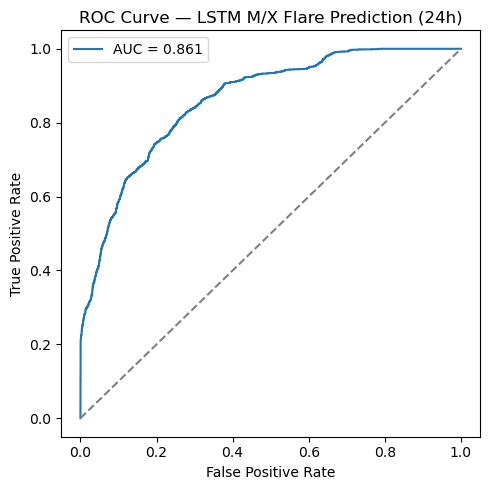

In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LSTM M/X Flare Prediction (24h)")
plt.legend()
plt.tight_layout()
plt.show()


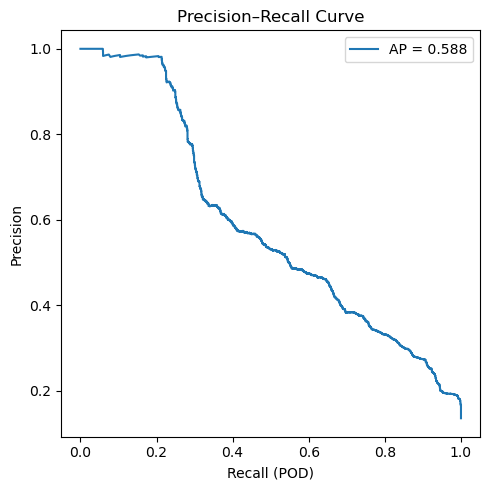

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, val_probs)
ap = average_precision_score(y_val, val_probs)

plt.figure(figsize=(5,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall (POD)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()


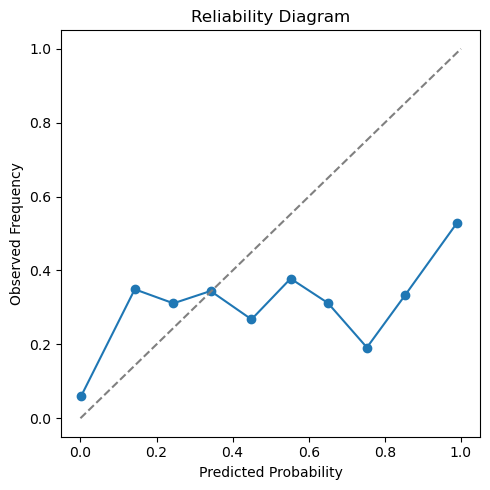

In [50]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_val, val_probs, n_bins=10)

plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Reliability Diagram")
plt.tight_layout()
plt.show()


In [53]:
from sklearn.metrics import confusion_matrix
import numpy as np

thresholds = np.linspace(0.01, 0.99, 99)
tss_vals = []

for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(val_truth, preds).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = tpr - fpr
    tss_vals.append(tss)

tss_vals = np.array(tss_vals)

best_idx = np.argmax(tss_vals)
best_thr = thresholds[best_idx]
best_tss = tss_vals[best_idx]

print(f"Best TSS = {best_tss:.4f} at threshold = {best_thr:.3f}")


Best TSS = 0.5287 at threshold = 0.060


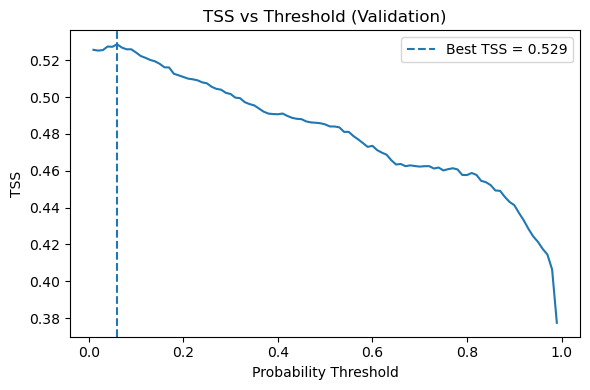

In [54]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, tss_vals)
plt.axvline(best_thr, linestyle="--", label=f"Best TSS = {best_tss:.3f}")
plt.xlabel("Probability Threshold")
plt.ylabel("TSS")
plt.title("TSS vs Threshold (Validation)")
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
import os, json, torch
from sklearn.metrics import roc_auc_score

os.makedirs("models", exist_ok=True)

# Recompute val AUC safely from stored predictions
val_auc = roc_auc_score(val_truth, val_probs)

model_metadata = {
    "model_type": "LSTMFlare",
    "seq_len": 120,
    "prediction_window_hours": 24,
    "input_dim": int(X_train.shape[2]),
    "hidden_dim": int(model.lstm.hidden_size),
    "num_layers": int(model.lstm.num_layers),
    "pos_weight": float(pos_weight),
    "feature_columns": feature_cols,
    "val_auc": float(val_auc),
    "best_tss": float(best_tss),
    "best_threshold": float(best_thr),
    "num_train_sequences": int(len(X_train)),
    "num_val_sequences": int(len(X_val)),
    "train_positive_fraction": float(y_train.mean()),
    "val_positive_fraction": float(y_val.mean()),
}

# Save model weights
torch.save(model.state_dict(), "models/lstm_best_state_dict.pth")

# Save metadata
with open("models/lstm_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("✅ Model saved successfully")
print("   - models/lstm_best_state_dict.pth")
print("   - models/lstm_metadata.json")
print("Val AUC:", val_auc)


✅ Model saved successfully
   - models/lstm_best_state_dict.pth
   - models/lstm_metadata.json
Val AUC: 0.8607215659950748
